# Reconstructing a probability distribution

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

import QCut as ck
from QCut import cutGate

A cut experiment estimates expectation values, so there are no counts to tally. Passing `qubits` instead of `observables` reconstructs the distribution over those qubits.

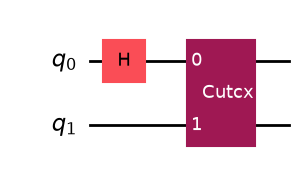

In [2]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.append(**cutGate(CXGate(), 0, 1))

circuit.decompose(gates_to_decompose=["CutGate"]).draw("mpl")

In [3]:
cut_circuit = ck.get_locations_and_subcircuits(circuit)
cut_experiment = ck.get_experiment_circuits(cut_circuit, qubits=[0, 1])

cut_experiment.observables

SparsePauliOp(['IZ', 'ZI', 'ZZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])

In [4]:
results = ck.run_experiments(cut_experiment, shots=4096, backend=AerSimulator())

probs = ck.estimate_probabilities(results)
probs

QuasiProbabilities({'00': 0.5086966454982758, '01': 0.0019234716892242432, '10': -0.0019686520099639893, '11': 0.491348534822464})

The values are quasi-probabilities, so one can come out negative. `nearest_probabilities()` gives the closest true distribution and `counts()` scales it by the shots the experiment ran at.

All three of these views report the ten most likely bitstrings by default. This distribution only has four, so nothing is left out here; pass `top` for a different number, or `top=None` for the whole distribution.

In [5]:
probs.nearest_probabilities()

{'00': 0.5080404281616211,
 '01': 0.00126725435256958,
 '10': 0.0,
 '11': 0.4906923174858093}

In [6]:
probs.counts()

{'00': 2080.93359375, '01': 5.190673828125, '10': 0.0, '11': 2009.875732421875}

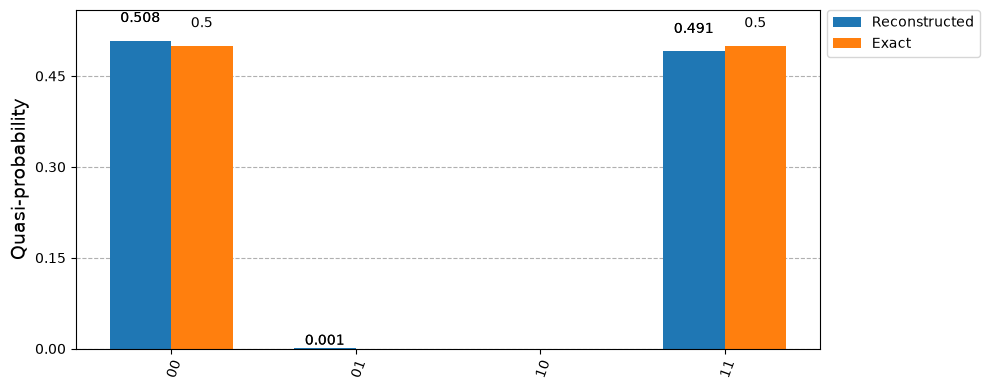

In [7]:
exact = Statevector(bell).probabilities_dict()

plot_histogram(
    [probs.nearest_probabilities(), exact],
    legend=["Reconstructed", "Exact"],
    figsize=(10, 4),
)

## Asking for part of the distribution

`nearest_probabilities()` and `counts()` expand the whole distribution, which is `2**k` values, whatever `top` they are given: the projection depends on every value. These three never expand it, so they stay affordable however many qubits the distribution spans.

In [8]:
# the most likely bitstrings, exactly, without expanding the rest
print(probs.top(2))

# one bitstring, without the others
print(probs.probability_of("01"))

# summed over every qubit but this one
print(probs.marginal([0]))


{'00': 0.5086966454982758, '11': 0.491348534822464}
0.0019234716892242432
QuasiProbabilities({'0': 0.5067279934883118, '1': 0.49327200651168823})


Neither the circuits nor the reading grow with how many qubits are asked for. Every Z string commutes with the others, so they share one measurement setting, and the distribution is held as a product over the subcircuits rather than as a table of `2**k` values. The observables are only built if something asks for them.

In [9]:
wide = QuantumCircuit(6)
wide.h(0)
wide.append(**cutGate(CXGate(), 0, 1))
for qubit in range(1, 5):
    wide.cx(qubit, qubit + 1)

for width in (2, 4, 6):
    experiment = ck.get_experiment_circuits(
        ck.get_locations_and_subcircuits(wide), qubits=list(range(width))
    )
    print(
        f"{width} qubits: {len(experiment.observables):3d} observables, "
        f"{experiment.num_obs_groups} measurement setting, "
        f"{experiment.num_circuits} circuits"
    )

2 qubits:   3 observables, 1 measurement setting, 12 circuits
4 qubits:  15 observables, 1 measurement setting, 12 circuits
6 qubits:  63 observables, 1 measurement setting, 12 circuits
